<a href="https://colab.research.google.com/github/Nancyrana1/scikit-learn/blob/main/scikitlearn1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import all the basic libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style='whitegrid')

Feature Extraction

1---> DictVectorizer

In [ ]:
data=[
    {'age':4,'height':96.0},
    {'age':1,'height':73.9},
    {'age':3,'height':88.9},
    {'age':2,'height':81.6},
]

In [ ]:
import sklearn
from sklearn.feature_extraction import DictVectorizer
dv = DictVectorizer(sparse=False)
data_transformed=dv.fit_transform(data)
data_transformed

array([[ 4. , 96. ],
       [ 1. , 73.9],
       [ 3. , 88.9],
       [ 2. , 81.6]])

In [ ]:
data_transformed.shape

(4, 2)

DATA IMPUTATION

HANDLING MISSING VALUES

In [ ]:
from sklearn.impute import SimpleImputer

Some of its important parameters:

missing_values: Could be int, float, str, np.nan or None. Default is np.nan.

**strategy**: string, default is 'mean'. One the following strategies can be used:

**mean **– missing values are replaced using the mean along each column

**median** – missing values are replaced using the median along each column

**most_frequent** – missing values are replaced using the most frequent along each column

**constant **– missing values are replaced with value specified in fill_value argument.

add_indicator is a boolean parameter that when set to True returns missing value indicators in indicator_ member variable.

Note:

mean and mode strategies can only be used with numeric data.

most_frequent and constant strategies can be used with strings or numeric data.

Data imputation on real world dataset

Let's perform data imputation on real world dataset. We will be using **heart-disease dataset from uci machine learning repository** for this purpose. We will load this dataset from csv file.

In [ ]:
cols = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
        'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

heart_data = pd.read_csv(
    'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data',
    header=None,
    names=cols
)

The dataset has the following features:

Age (in years)

Sex (1 = male; 0 = female)

cp – chest pain type

trestbps – resting blood pressure (anything above 130–140 is typically cause for concern)

chol – serum cholesterol in mg/dl (above 200 is cause for concern)

fbs – fasting blood sugar (> 120 mg/dl) (1 = true; 0 = false)

restecg – resting electrocardiographic results

0 = normal

1 = having ST-T wave abnormality

2 = showing probable or definite left ventricular hypertrophy by Estes' criteria

thalach – maximum heart rate achieved

exang – exercise induced angina

1 = yes

0 = no

oldpeak – depression induced by exercise relative to rest

slope – slope of the peak exercise ST segment

1 = upsloping

2 = flat value

3 = downsloping

ca – number of major vessels (0–3) colored by fluoroscopy

thal – (3 = normal; 6 = fixed defect; 7 = reversible defect)

num – diagnosis of heart disease (angiographic disease status)

0 = < 50% diameter narrowing

1 = > 50% diameter narrowing

# checking for missing values

In [ ]:
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  num       303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


In [ ]:
heart_data.isna()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,False,False,False,False,False,False,False,False,False,False,False,False,False,False
299,False,False,False,False,False,False,False,False,False,False,False,False,False,False
300,False,False,False,False,False,False,False,False,False,False,False,False,False,False
301,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
heart_data.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
heart_data.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
print(heart_data['age'].unique())
print('\n')
print(heart_data['sex'].unique())
print('\n')
print(heart_data['cp'].unique())
print('\n')
print(heart_data['trestbps'].unique())
print('\n')
print(heart_data['chol'].unique())
print('\n')
print(heart_data['fbs'].unique())
print('\n')
print(heart_data['restecg'].unique())
print('\n')
print(heart_data['thalach'].unique())
print('\n')
print(heart_data['exang'].unique())
print('\n')
print(heart_data['oldpeak'].unique())
print('\n')
print(heart_data['slope'].unique())
print('\n')
print(heart_data['ca'].unique())
print('\n')
print(heart_data['thal'].unique())
print('\n')
print(heart_data['num'].unique())

[63. 67. 37. 41. 56. 62. 57. 53. 44. 52. 48. 54. 49. 64. 58. 60. 50. 66.
 43. 40. 69. 59. 42. 55. 61. 65. 71. 51. 46. 45. 39. 68. 47. 34. 35. 29.
 70. 77. 38. 74. 76.]


[1. 0.]


[1. 4. 3. 2.]


[145. 160. 120. 130. 140. 172. 150. 110. 132. 117. 135. 112. 105. 124.
 125. 142. 128. 170. 155. 104. 180. 138. 108. 134. 122. 115. 118. 100.
 200.  94. 165. 102. 152. 101. 126. 174. 148. 178. 158. 192. 129. 144.
 123. 136. 146. 106. 156. 154. 114. 164.]


[233. 286. 229. 250. 204. 236. 268. 354. 254. 203. 192. 294. 256. 263.
 199. 168. 239. 275. 266. 211. 283. 284. 224. 206. 219. 340. 226. 247.
 167. 230. 335. 234. 177. 276. 353. 243. 225. 302. 212. 330. 175. 417.
 197. 198. 290. 253. 172. 273. 213. 305. 216. 304. 188. 282. 185. 232.
 326. 231. 269. 267. 248. 360. 258. 308. 245. 270. 208. 264. 321. 274.
 325. 235. 257. 164. 141. 252. 255. 201. 222. 260. 182. 303. 265. 309.
 307. 249. 186. 341. 183. 407. 217. 288. 220. 209. 227. 261. 174. 281.
 221. 205. 240. 289. 318. 298. 564. 246. 322. 299.

#filling missing '?' with NAN

counting "?" in ca and thal

In [ ]:
print('missing values in ca :', heart_data.loc[heart_data.ca=='?','ca'].count())
print('missing values in thal :', heart_data.loc[heart_data.thal=='?','thal'].count())

missing values in ca : 4
missing values in thal : 2


In [ ]:
heart_data.replace('?',np.nan,inplace=True)

reaplace ? with nana

#We will try two variations –

• add_indicator = False: Default choice that only imputes missing values.

In [ ]:
from sklearn.impute import SimpleImputer
si=SimpleImputer(missing_values=np.nan,strategy='mean')
heart_data_new=si.fit_transform(heart_data)
heart_data_new.shape


(303, 14)

In [ ]:
heart_data_new

array([[63.       ,  1.       ,  1.       , ...,  0.       ,  6.       ,
         0.       ],
       [67.       ,  1.       ,  4.       , ...,  3.       ,  3.       ,
         2.       ],
       [67.       ,  1.       ,  4.       , ...,  2.       ,  7.       ,
         1.       ],
       ...,
       [57.       ,  1.       ,  4.       , ...,  1.       ,  7.       ,
         3.       ],
       [57.       ,  0.       ,  2.       , ...,  1.       ,  3.       ,
         1.       ],
       [38.       ,  1.       ,  3.       , ...,  0.6722408,  3.       ,
         0.       ]])

#add_indicator = True:
 Adds additional column for each column containing missing values. In our case, this adds two columns one for ca and other for thal. It indicates if the sample has a missing value.

In [ ]:
si=SimpleImputer(add_indicator=True,missing_values=np.nan,strategy='mean')
heart_data_with_addIndicator=si.fit_transform(heart_data)
heart_data_with_addIndicator.shape

(303, 16)

In [ ]:
heart_data_with_addIndicator

array([[63.,  1.,  1., ...,  0.,  0.,  0.],
       [67.,  1.,  4., ...,  2.,  0.,  0.],
       [67.,  1.,  4., ...,  1.,  0.,  0.],
       ...,
       [57.,  1.,  4., ...,  3.,  0.,  0.],
       [57.,  0.,  2., ...,  1.,  0.,  0.],
       [38.,  1.,  3., ...,  0.,  1.,  0.]])

#feature scaling

Feature scaling transforms feature values such that all the features are on the same scale.

When we use feature matrix with all features on the same scale, it provides us certain advantages as listed below:

Enables faster convergence in iterative optimization algorithms like gradient descent and its variants.

The performance of ML algorithms such as SVM, K-NN and K-means etc that compute euclidean distance among input samples gets impacted if the features are not scaled.

Tree based ML algorithms are not affected by feature-scaling. In other words, feature scaling is not required for tree based ML algorithms.

Feature scaling can be performed with the following methods:

**Standardization**

**Normalization**

**MaxAbsScaler**

Let's demonstrate feature scaling on a real world dataset. For this purpose we will be using **abalone dataset**. We will use different scaling utilities in sklearn library.

In [ ]:
cols = ['Sex', 'Length', 'Diameter', 'Height', 'Whole weight',
        'Shucked weight', 'Viscera weight', 'Shell weight', 'Rings']

abalone_data = pd.read_csv(
    'https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data',
    header=None,
    names=cols
)

# examine the dataset

In [ ]:
abalone_data.info()

abalone_data.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole weight    4177 non-null   float64
 5   Shucked weight  4177 non-null   float64
 6   Viscera weight  4177 non-null   float64
 7   Shell weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


Index(['Sex', 'Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight',
       'Viscera weight', 'Shell weight', 'Rings'],
      dtype='object')

# sex is non numeric data so for feature scaling we have to convert it

In [ ]:
abalone_data.Sex.unique()

array(['M', 'F', 'I'], dtype=object)

In [ ]:
# assigning the value
abalone_data=abalone_data.replace({'M':0,'F':1,'I':2})
abalone_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   int64  
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole weight    4177 non-null   float64
 5   Shucked weight  4177 non-null   float64
 6   Viscera weight  4177 non-null   float64
 7   Shell weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(2)
memory usage: 293.8 KB


/tmp/ipykernel_494/3589322911.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  abalone_data=abalone_data.replace({'M':0,'F':1,'I':2})


# separate label from the features
as you can't perform feature scaling on labels

In [ ]:
abalone_data.columns

Index(['Sex', 'Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight',
       'Viscera weight', 'Shell weight', 'Rings'],
      dtype='object')

In [ ]:
y=abalone_data.pop('Rings')
print("after deleting the column : ")

abalone_data.info()

after deleting the column : 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   int64  
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole weight    4177 non-null   float64
 5   Shucked weight  4177 non-null   float64
 6   Viscera weight  4177 non-null   float64
 7   Shell weight    4177 non-null   float64
dtypes: float64(7), int64(1)
memory usage: 261.2 KB


In [ ]:
abalone_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Sex,4177.0,0.955470,0.827815,0.0000,0.0000,1.0000,2.000,2.0000
Length,4177.0,0.523992,0.120093,0.0750,0.4500,0.5450,0.615,0.8150
Diameter,4177.0,0.407881,0.099240,0.0550,0.3500,0.4250,0.480,0.6500
Height,4177.0,0.139516,0.041827,0.0000,0.1150,0.1400,0.165,1.1300
Whole weight,4177.0,0.828742,0.490389,0.0020,0.4415,0.7995,1.153,2.8255
Shucked weight,4177.0,0.359367,0.221963,0.0010,0.1860,0.3360,0.502,1.4880
Viscera weight,4177.0,0.180594,0.109614,0.0005,0.0935,0.1710,0.253,0.7600
Shell weight,4177.0,0.238831,0.139203,0.0015,0.1300,0.2340,0.329,1.0050


#observe the difference between the mean and the std deviation of the columns

#visualise (using diff plots or statistical methods)

<Axes: xlabel='Length', ylabel='Count'>

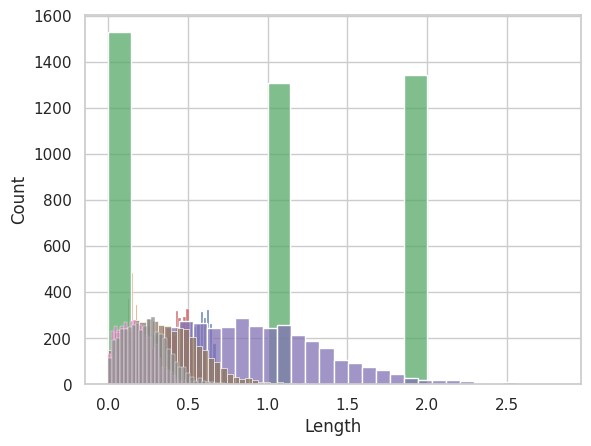

In [ ]:
sns.histplot(abalone_data.Length)
sns.histplot(abalone_data.Height)
sns.histplot(abalone_data.Sex)
sns.histplot(abalone_data.Diameter)
sns.histplot(data=abalone_data['Whole weight'])
sns.histplot(data=abalone_data['Shucked weight'])
sns.histplot(data=abalone_data['Viscera weight'])
sns.histplot(data=abalone_data['Shell weight'])

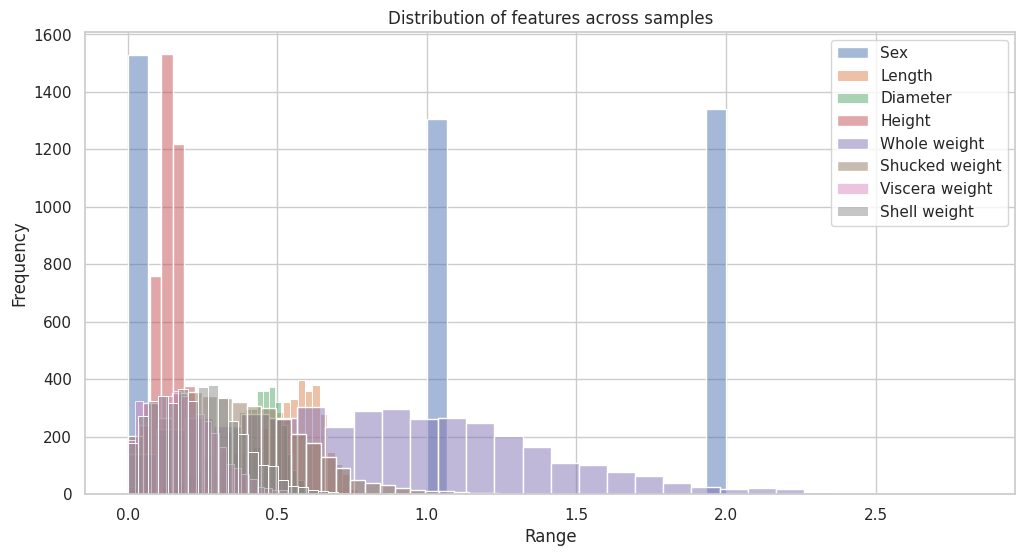

In [ ]:
# histogram plot
# ALPHA maintains the transparency


plt.figure(figsize=(12,6))

for col in abalone_data.columns:
    sns.histplot(abalone_data[col], kde=False, bins=30, label=col, alpha=0.5)

plt.title("Distribution of features across samples")
plt.xlabel("Range")
plt.ylabel("Frequency")
plt.legend()
plt.show()

Kernel Density Estimation is a method to estimate the probability density function (PDF) of a dataset.
It creates a smooth curve that represents the distribution of the data.

Instead of showing bars like a histogram, KDE shows a continuous smooth line.

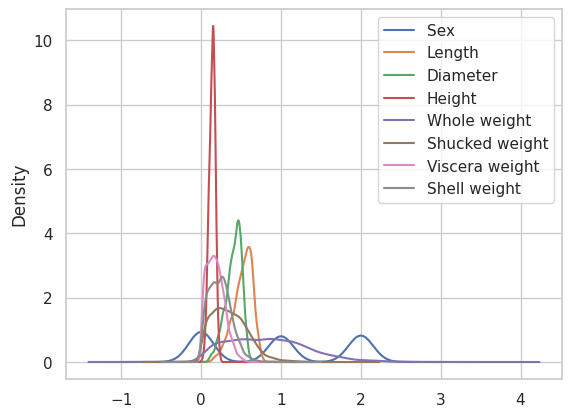

In [ ]:
kd_plot=abalone_data.plot.kde()

#voilin plot
A Violin Plot combines features of:

    Box Plot

    Kernel Density Plot

It shows:

    data distribution

    median

    quartiles

    density shape

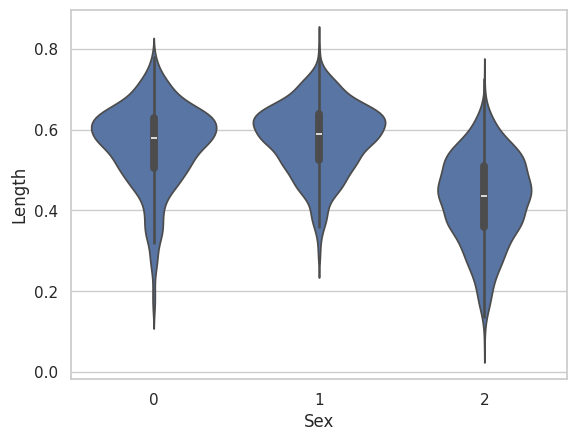

In [ ]:
sns.violinplot(x=abalone_data['Sex'], y=abalone_data['Length'])
plt.show()

# Box Plot 📦

A Box Plot (Box-and-Whisker Plot) is a visualization used to show the distribution of numerical data using summary statistics.

It helps quickly identify:

    Median

    Spread of data

    Outliers

    Quartiles

Libraries like Matplotlib and Seaborn are commonly used to create box plots.

Components of a Box Plot
1️⃣ Minimum

The smallest value in the dataset (excluding extreme outliers).

2️⃣ First Quartile (Q1)

25% of the data lies below this value.

3️⃣ Median (Q2)

The middle value of the dataset.

4️⃣ Third Quartile (Q3)

75% of the data lies below this value.

5️⃣ Maximum

The largest value in the dataset (excluding outliers).

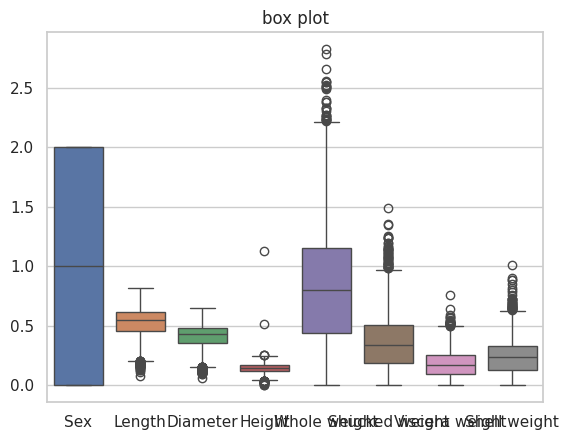

In [ ]:
sns.boxplot(data=abalone_data)
plt.title("box plot")
plt.show()

In [ ]:
x=np.array([4,2,5,-2,-100]).reshape(-1,1)
print(x)

[[   4]
 [   2]
 [   5]
 [  -2]
 [-100]]


In [ ]:
from sklearn.preprocessing import MaxAbsScaler
mas=MaxAbsScaler()
x_new=mas.fit_transform(x)
x_new

array([[ 0.04],
       [ 0.02],
       [ 0.05],
       [-0.02],
       [-1.  ]])

In [ ]:
from sklearn.preprocessing import MinMaxScaler
mms=MinMaxScaler()
x_new=mms.fit_transform(x)
x_new

array([[0.99047619],
       [0.97142857],
       [1.        ],
       [0.93333333],
       [0.        ]])

In [ ]:
data = pd.DataFrame(data, columns=abalone_data.columns)
data=mms.fit_transform(abalone_data)
data[:5]

array([[0.        , 0.51351351, 0.5210084 , 0.0840708 , 0.18133522,
        0.15030262, 0.1323239 , 0.14798206],
       [0.        , 0.37162162, 0.35294118, 0.07964602, 0.07915707,
        0.06624075, 0.06319947, 0.06826109],
       [0.5       , 0.61486486, 0.61344538, 0.11946903, 0.23906499,
        0.17182246, 0.18564845, 0.2077728 ],
       [0.        , 0.49324324, 0.5210084 , 0.11061947, 0.18204356,
        0.14425017, 0.14944042, 0.15296462],
       [1.        , 0.34459459, 0.33613445, 0.07079646, 0.07189658,
        0.0595158 , 0.05134957, 0.0533134 ]])

In [ ]:
data.mean(axis=0)

array([0.47773522, 0.60674608, 0.59307774, 0.12346584, 0.29280756,
       0.24100033, 0.23712127, 0.2365031 ])

In [ ]:
data.std(axis=0)

array([0.4138578 , 0.16226829, 0.16676972, 0.03701066, 0.17366046,
       0.14925109, 0.14430695, 0.13870055])

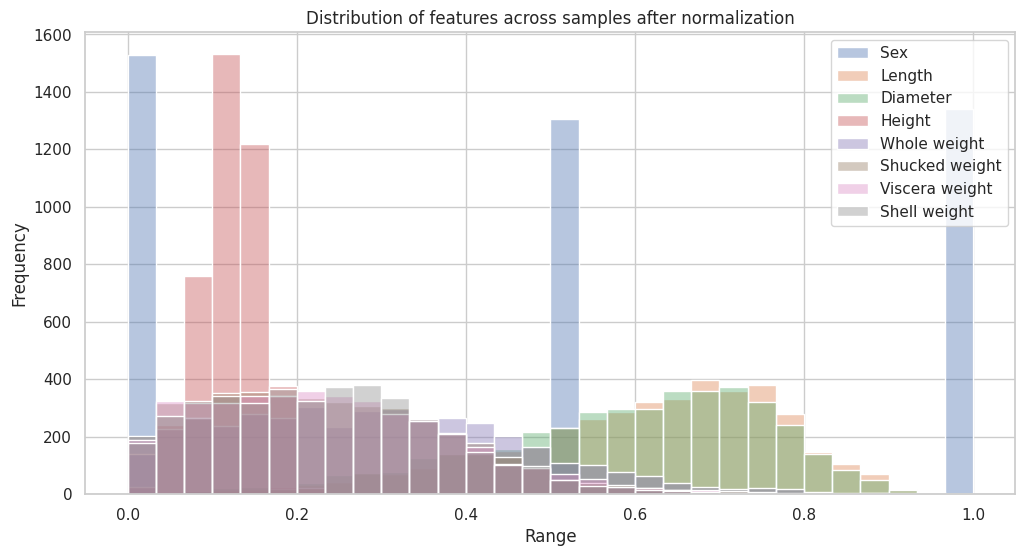

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

data = pd.DataFrame(data, columns=abalone_data.columns)
plt.figure(figsize=(12,6))

for col in data.columns:
    sns.histplot(data[col], bins=30, alpha=0.4, label=col)

plt.title("Distribution of features across samples after normalization")
plt.xlabel("Range")
plt.ylabel("Frequency")
plt.legend()
plt.show()

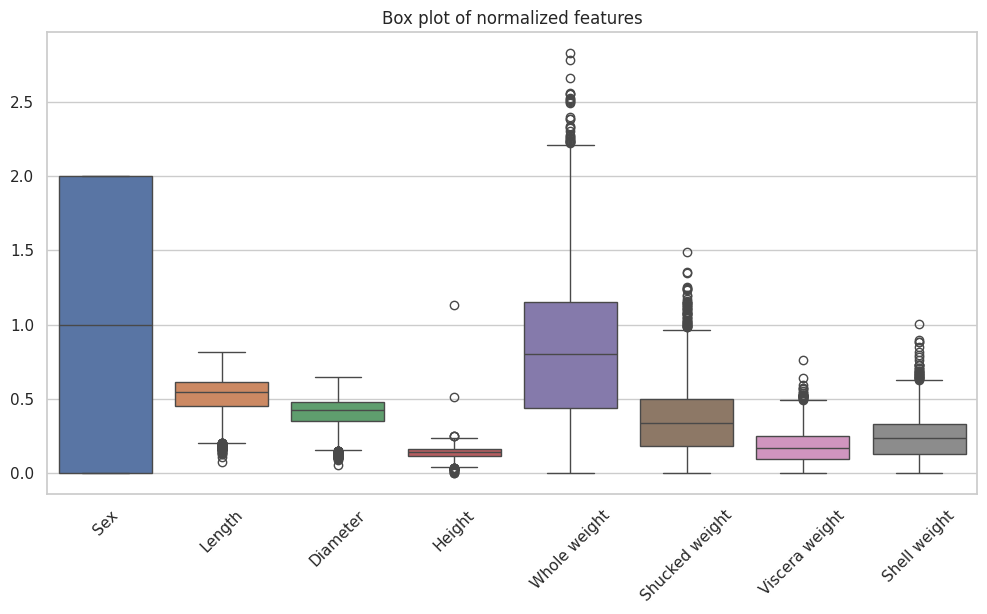

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(data=abalone_data)

plt.xticks(rotation=45)
plt.title("Box plot of normalized features")
plt.show()


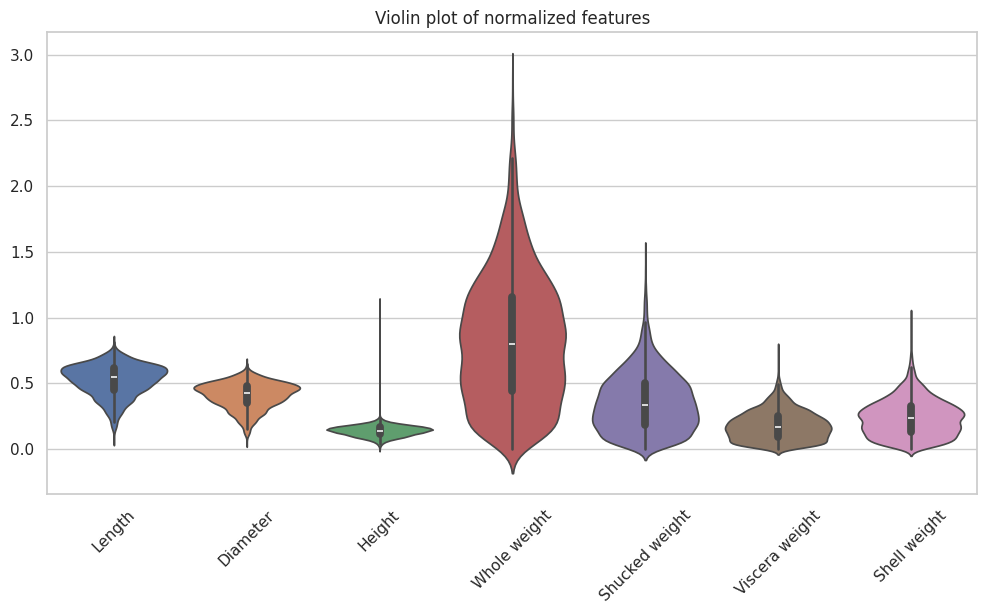

In [ ]:
plt.figure(figsize=(12,6))

sns.violinplot(data=abalone_data.drop('Sex', axis=1))

plt.xticks(rotation=45)
plt.title("Violin plot of normalized features")
plt.show()

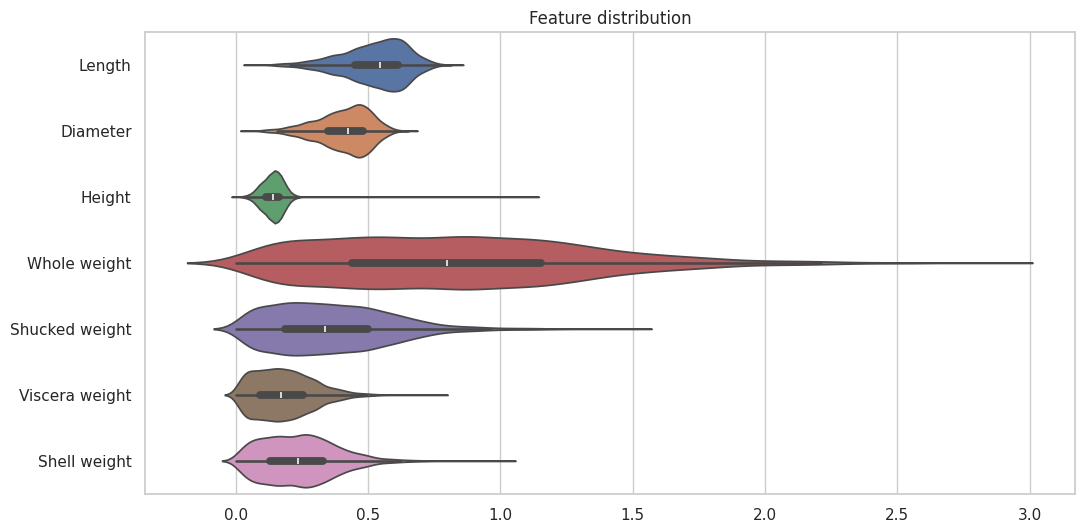

In [ ]:
plt.figure(figsize=(12,6))

sns.violinplot(data=abalone_data.drop('Sex', axis=1), orient="h")

plt.title("Feature distribution")
plt.show()

# standardization using "StandardScaler"

In [ ]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
data=ss.fit_transform(abalone_data)
data[:5]

array([[-1.15434629, -0.57455813, -0.43214879, -1.06442415, -0.64189823,
        -0.60768536, -0.72621157, -0.63821689],
       [-1.15434629, -1.44898585, -1.439929  , -1.18397831, -1.23027711,
        -1.17090984, -1.20522124, -1.21298732],
       [ 0.05379815,  0.05003309,  0.12213032, -0.10799087, -0.30946926,
        -0.4634999 , -0.35668983, -0.20713907],
       [-1.15434629, -0.69947638, -0.43214879, -0.34709919, -0.63781934,
        -0.64823753, -0.60759966, -0.60229374],
       [ 1.26194258, -1.61554351, -1.54070702, -1.42308663, -1.27208566,
        -1.2159678 , -1.28733718, -1.32075677]])

In [ ]:
data.mean(axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1.])

In [ ]:
data.std(axis=0)


array([1., 1., 1., 1., 1., 1., 1., 1.])

# ADD_dummy_feature


do add a parameter for bias term



In [ ]:
v=np.array([[7,1],
[1,8],
[2,0],
[9,6]])

from sklearn.preprocessing import add_dummy_feature
x_new = add_dummy_feature(v)
x_new

array([[1., 7., 1.],
       [1., 1., 8.],
       [1., 2., 0.],
       [1., 9., 6.]])

#custom transformers
eg== polynomial


### FunctionTransformer

In [ ]:
from sklearn.preprocessing import FunctionTransformer


For this demonstration, we will be using a wine quality dataset from UCI machine learning repository.

It has got the following attributes:

fixed acidity

volatile acidity

citric acid

residual sugar

chlorides

free sulfur dioxide

total sulfur dioxide

density

pH

sulphates

alcohol

quality (Output: score between 0 and 10)

In [ ]:
wine_data = pd.read_csv(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv",
    sep=";"
)

wine_data.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000
